<a href="https://colab.research.google.com/github/Kkurzo/-labs/blob/main/%D0%9B%D0%B0%D0%B12_3_Amason_%D0%9C%D0%B5%D0%BB%D1%8C%D0%BD%D0%B8%D1%87%D1%83%D0%BA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("sootersaalu/amazon-top-50-bestselling-books-2009-2019")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-top-50-bestselling-books-2009-2019' dataset.
Path to dataset files: /kaggle/input/amazon-top-50-bestselling-books-2009-2019


In [7]:
df = pd.read_csv(os.path.join(path, "bestsellers with categories.csv"))
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


Опис датасету

Датасет містить інформацію про книги та їхню популярність серед читачів. Він може використовуватися для аналізу того, як рейтинг, кількість відгуків, ціна, рік видання та жанр пов'язані між собою.


**Name**	Назва книги

**Author**	Автор книги

**User Rating**	Середня оцінка книги користувачами за 5-бальною шкалою

**Reviews**	Кількість відгуків користувачів

**Price**	Ціна книги

**Year**	Рік видання

**Genre	Жанр книги**: Fiction або Non Fiction

In [8]:
df.shape

(550, 7)

In [9]:
df.isnull().sum()

,0
Name,0
Author,0
User Rating,0
Reviews,0
Price,0
Year,0
Genre,0


In [11]:
df.duplicated(subset="Name").sum()


np.int64(199)

In [12]:
df = df.drop_duplicates(subset="Name")

In [13]:
df.shape

(351, 7)

Про скільки книг зберігає дані датасет?
550 книг
351 унікальні

In [17]:
df.columns = ["name", "author", "user_rating", "reviews", "price", "year", "ganre"]
df.head()

,name,author,user_rating,reviews,price,year,ganre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 351 entries, 0 to 546
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         351 non-null    object 
 1   author       351 non-null    object 
 2   user_rating  351 non-null    float64
 3   reviews      351 non-null    int64  
 4   price        351 non-null    int64  
 5   year         351 non-null    int64  
 6   ganre        351 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 21.9+ KB


In [19]:
df.isna().sum()

,0
name,0
author,0
user_rating,0
reviews,0
price,0
year,0
ganre,0


In [20]:
df["ganre"].value_counts()

,count
ganre,
Non Fiction,191
Fiction,160


In [21]:
df["ganre"].unique()

array(['Non Fiction', 'Fiction'], dtype=object)

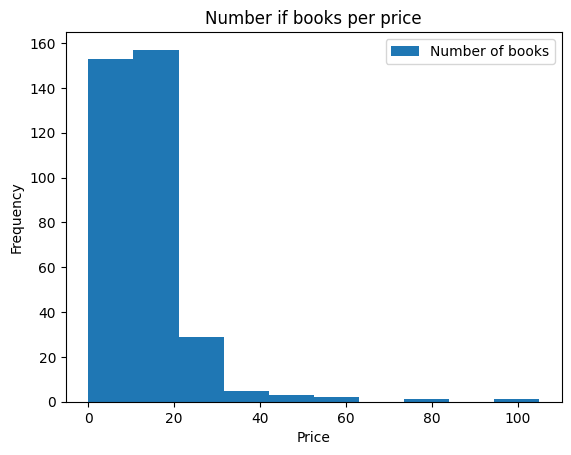

In [22]:
df["price"].plot(kind="hist", label="Number of books")
plt.xlabel("Price")
plt.title("Number if books per price")
plt.legend()
plt.show()

In [23]:
df["price"].describe()

,price
count,351.000000
mean,13.076923
std,10.050860
min,0.000000
25%,8.000000
50%,12.000000
75%,16.000000
max,105.000000


In [27]:
df["price"].max()

105

In [28]:
df["price"].min()

0

In [29]:
df["price"].mean()

np.float64(13.076923076923077)

In [30]:
df["price"].median()

12.0

In [32]:
df["user_rating"].max()

4.9

In [34]:
df[df["user_rating"] == 4.9]["name"].count()

np.int64(28)

In [35]:
df[df["reviews"] == df["reviews"].max()]

,name,author,user_rating,reviews,price,year,ganre
534,Where the Crawdads Sing,Delia Owens,4.8,87841,15,2019,Fiction


In [37]:
max_price = df[df['year'] == 2015]["price"].max()
df[(df["year"] == 2015) & (df["price"] == max_price)]

,name,author,user_rating,reviews,price,year,ganre
132,Go Set a Watchman: A Novel,Harper Lee,3.6,14982,19,2015,Fiction


In [41]:
df[(df["year"] == 2010) & (df["ganre"] == "Fiction")].count()["name"]

np.int64(17)

In [43]:
df[(df["user_rating"] == 4.9) & ((df["year"] == 2010) | (df["year"] == 2011))]

,name,author,user_rating,reviews,price,year,ganre
187,Jesus Calling: Enjoying Peace in His Presence ...,Sarah Young,4.9,19576,8,2011,Non Fiction


In [45]:
df[(df["price"] < 8) & (df["year"] == 2015)].sort_values("price")

,name,author,user_rating,reviews,price,year,ganre
54,Creative Haven Creative Cats Coloring Book (Ad...,Marjorie Sarnat,4.8,4022,4,2015,Non Fiction
123,Giraffes Can't Dance,Giles Andreae,4.8,14038,4,2015,Fiction
55,Creative Haven Owls Coloring Book (Adult Color...,Marjorie Sarnat,4.8,3871,5,2015,Non Fiction
28,Baby Touch and Feel: Animals,DK,4.6,5360,5,2015,Non Fiction
63,Dear Zoo: A Lift-the-Flap Book,Rod Campbell,4.8,10922,5,2015,Fiction
89,Dover Creative Haven Art Nouveau Animal Design...,Marty Noble,4.6,2134,5,2015,Non Fiction
201,Killing Reagan: The Violent Assault That Chang...,Bill O'Reilly,4.6,5235,5,2015,Non Fiction
16,Adult Coloring Book: Stress Relieving Animal D...,Blue Star Coloring,4.6,2925,6,2015,Non Fiction
17,Adult Coloring Book: Stress Relieving Patterns,Blue Star Coloring,4.4,2951,6,2015,Non Fiction
253,Old School (Diary of a Wimpy Kid #10),Jeff Kinney,4.8,6169,7,2015,Fiction


In [47]:
df.groupby(["ganre"])[["price"]].agg([np.min, np.max])

/tmp/ipykernel_1161/2477537950.py:1: FutureWarning: The provided callable <function min at 0x798e92d5b6a0> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df.groupby(["ganre"])[["price"]].agg([np.min, np.max])
/tmp/ipykernel_1161/2477537950.py:1: FutureWarning: The provided callable <function max at 0x798e92d5b560> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df.groupby(["ganre"])[["price"]].agg([np.min, np.max])


price     
              min  max
ganre                 
Fiction         0   82
Non Fiction     0  105

In [50]:
author_books = df.groupby(["author"])[["name"]].count()
author_books

,name
author,
Abraham Verghese,1
Adam Gasiewski,1
Adam Mansbach,1
Adir Levy,1
Admiral William H. McRaven,1
...,...
Walter Isaacson,2
William Davis,1
William P. Young,1
